In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [26]:
df = pd.read_csv('data_science_job.csv')


In [27]:
df.head()


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [28]:
df.isnull().sum()


enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [29]:
df.isnull().mean()*100


enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [30]:
df.shape


(19158, 13)

In [31]:
#on which columns to apply cca - the one is which at max only 5% data is missing like city_development index ,etc

In [32]:
 #cols we are gong to apply cca on :-
 cols = [var for var in df.columns if df[var].isnull().mean() <0.05 and df[var].isnull().mean() >0]

In [33]:
cols


['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [34]:
df[cols].sample(10)


,city_development_index,enrolled_university,education_level,experience,training_hours
14510,0.887,Full time course,Graduate,3.0,35.0
16229,0.830,no_enrollment,Graduate,15.0,310.0
2661,0.754,no_enrollment,High School,20.0,116.0
12003,0.920,no_enrollment,Phd,14.0,4.0
13030,0.910,no_enrollment,Graduate,20.0,18.0
2619,0.624,no_enrollment,Graduate,2.0,316.0
2212,0.804,no_enrollment,Masters,5.0,48.0
2249,0.767,Part time course,Masters,4.0,74.0
12791,0.910,Part time course,Graduate,10.0,17.0
17971,0.920,no_enrollment,Masters,3.0,50.0


In [35]:
len(df[cols].dropna()) #rows left after removing rows with missing data


17182

In [36]:
#data retained on removing rows with missing values from above data
len(df[cols].dropna())/len(df)

0.8968577095730244

In [37]:
new_df = df[cols].dropna()
new_df.shape , df.shape


((17182, 5), (19158, 13))

In [46]:
new_df.sample(15)

,city_development_index,enrolled_university,education_level,experience,training_hours
14282,0.926,Full time course,Graduate,1.0,86.0
15715,0.804,Part time course,Graduate,10.0,73.0
17895,0.910,no_enrollment,Graduate,11.0,14.0
11038,0.920,no_enrollment,Graduate,8.0,15.0
4770,0.910,no_enrollment,Graduate,7.0,4.0
4187,0.920,no_enrollment,Graduate,4.0,17.0
133,0.666,no_enrollment,Graduate,20.0,290.0
10183,0.776,Full time course,Graduate,10.0,33.0
1087,0.624,no_enrollment,Graduate,2.0,65.0
8363,0.920,no_enrollment,Graduate,5.0,141.0


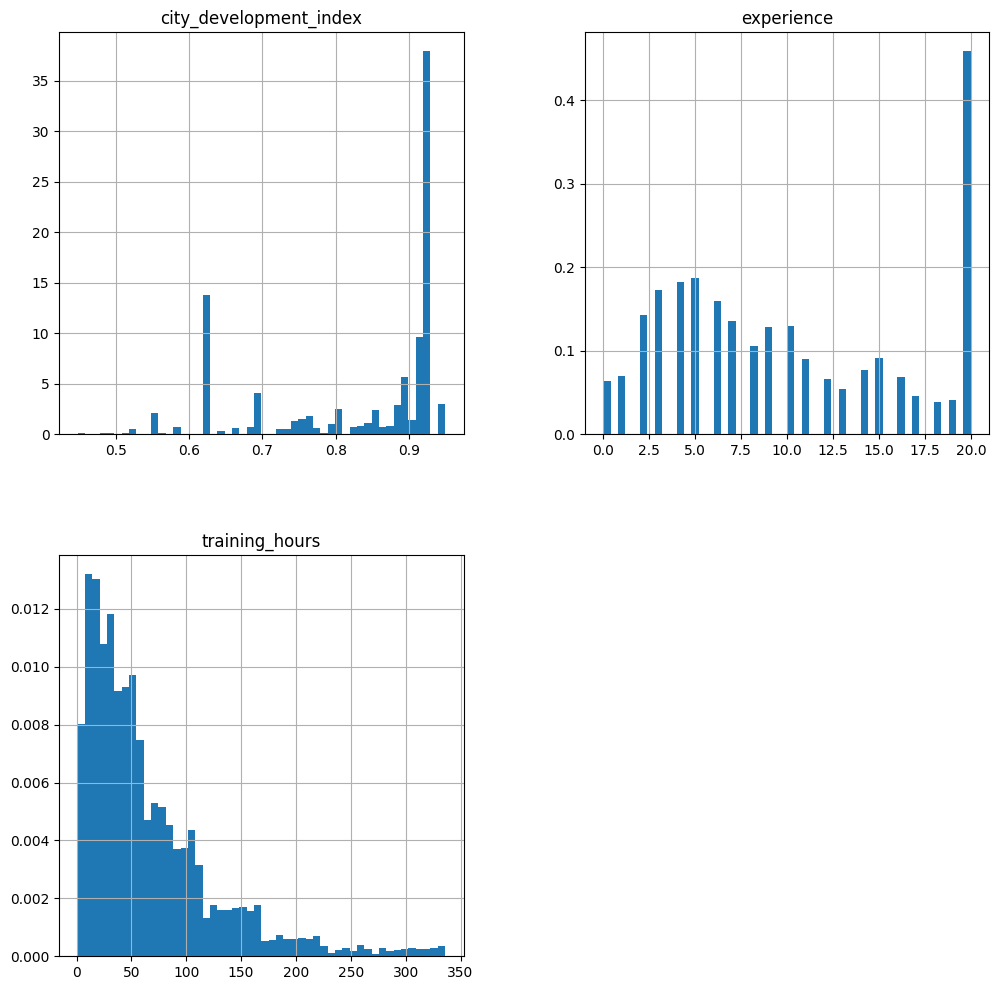

In [38]:
new_df.hist(bins = 50 , density = True , figsize = (12,12))
plt.show()

In [39]:
#plot histograms for cols with numerical data on which cca have been performed,  if both the data are comparable- go with it

<Axes: >

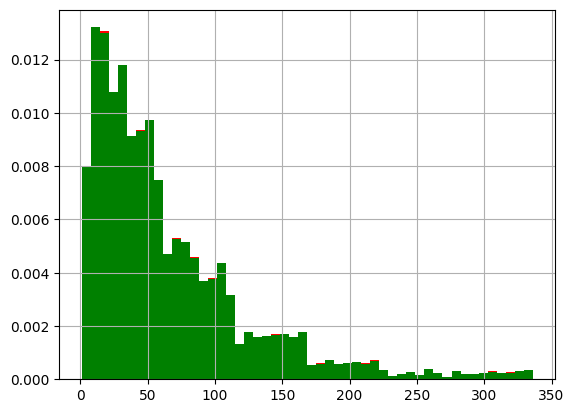

In [40]:
fig = plt.figure()
ax= fig.add_subplot(111)

#og data
df['training_hours'].hist(bins = 50 , ax= ax, density = True , color = 'red')

#data after the cca, the argument aplha makes the color transparent , so we can see the overlay of the 2 distributions

new_df['training_hours'].hist(bins = 50 , ax = ax, color = 'green', density = True)
#mostly overlapped

<Axes: ylabel='Density'>

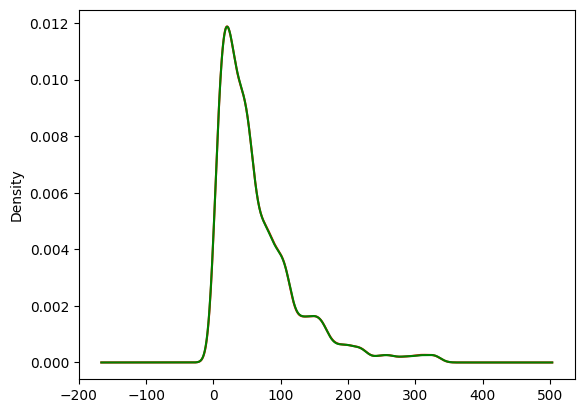

In [42]:
fig = plt.figure()
ax = fig.add_subplot(111)

#og data
df['training_hours'].plot.density(color= 'red')

#data after cca
new_df['training_hours'].plot.density(color = 'green')

<Axes: ylabel='Density'>

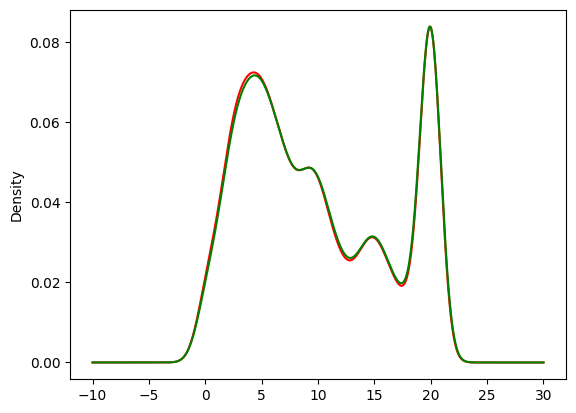

In [44]:
fig = plt.figure()
ax = fig.add_subplot(111)

#on og data(experience)

df['experience'].plot.density(color ='red')

#after applying cca
new_df['experience'].plot.density(color = 'green')

<Axes: ylabel='Density'>

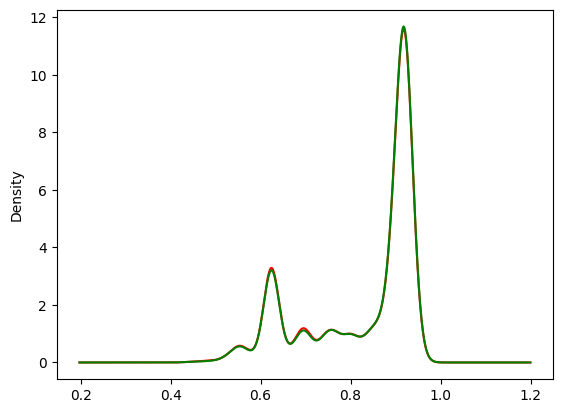

In [45]:
fig = plt.figure()
ax = fig.add_subplot(111)

#on og data(experience)

df['city_development_index'].plot.density(color ='red')

#after applying cca
new_df['city_development_index'].plot.density(color = 'green')

In [47]:
df[cols].sample(10)


,city_development_index,enrolled_university,education_level,experience,training_hours
18400,0.925,Full time course,High School,0.0,204.0
17810,0.887,no_enrollment,High School,20.0,33.0
16108,0.804,Full time course,High School,3.0,32.0
634,0.624,no_enrollment,Graduate,1.0,29.0
12409,0.624,no_enrollment,Graduate,5.0,28.0
12135,0.624,no_enrollment,Masters,9.0,246.0
12121,0.920,no_enrollment,Graduate,5.0,66.0
6269,0.804,no_enrollment,Graduate,7.0,33.0
11015,0.920,no_enrollment,Graduate,16.0,74.0
18055,0.698,NaN,NaN,NaN,NaN


applying cca on categorical cols


In [50]:
df['education_level'].value_counts() ,df['enrolled_university'].value_counts() ,

(education_level
 Graduate          11598
 Masters            4361
 High School        2017
 Phd                 414
 Primary School      308
 Name: count, dtype: int64,
 enrolled_university
 no_enrollment       13817
 Full time course     3757
 Part time course     1198
 Name: count, dtype: int64)

In [ ]:
#on applying cc to categorical cols , make sure that the ratio of the sub categories before = after .

In [55]:
temp = pd.concat([
    #%age of obs per category , og data
    df['enrolled_university'].value_counts()/len(df),

    # %age of obs per category , cca data
    new_df['enrolled_university'].value_counts() /len(df)
],
    axis = 1 )

#add cols names
temp.columns = ['original', 'cca']

temp


,original,cca
enrolled_university,,
no_enrollment,0.721213,0.659359
Full time course,0.196106,0.180029
Part time course,0.062533,0.057469


In [56]:
temp = pd.concat([
    #%age of obs per category , og data
    df['education_level'].value_counts()/len(df),

    # %age of obs per category , cca data
    new_df['education_level'].value_counts() /len(df)
],
    axis = 1 )

#add cols names
temp.columns = ['original', 'cca']

temp


,original,cca
education_level,,
Graduate,0.605387,0.555904
Masters,0.227633,0.209938
High School,0.105282,0.096304
Phd,0.021610,0.019835
Primary School,0.016077,0.014876
